# Exercise 1 

In this exercise, we will work with the `spam.csv` data file. This file contains text and a label attached to each text. The goal is to explore this data. 

### Exercise 1(a) (2 points)

Load the `pandas` and `numpy` libraries.

In [1]:
import pandas as pd
import numpy as np

### Exercise 1(b) (2 points)

Read the `csv` file and create a data-frame called `spam_df`.

In [2]:
spam_df = pd.read_csv('spam.csv')
spam_df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Exercise 1(c) (2 points)

Report the `shape` of `spam_df`.

In [3]:
spam_df.shape

(5572, 2)

### Exercise 1(d) (2 points)

Report the frequency table of `label`.

In [4]:
spam_df.value_counts('label', normalize=True)

label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

### Exercise 1(e) (2 points)

Using the `string` library, remove all the punctuation of the `text` column.

In [5]:
import string

spam_df['text_clean'] = spam_df['text'].str.replace(f"[]{string.punctuation}]", '', regex=True)
spam_df.head()

,label,text,text_clean
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...


### Exercise 1(f) (10 points)

Using the `nltk` library, remove stopwords and pronouns from `text_clean` and store in another column called `'text_clean_1'`. If you don't have `nltk` installed in your computer, run the following code:

```
pip install nltk
```

In [8]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stopwords = set(stopwords.words('english'))
pronouns = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves'])

def clean_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stopwords and word not in pronouns]
    return ' '.join(tokens)

spam_df['text_clean_1'] = spam_df['text_clean'].apply(clean_text)
spam_df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gmgma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


,label,text,text_clean,text_clean_1
0,ham,"Go until jurong point, crazy.. Available only ...",Go until jurong point crazy Available only in ...,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,Ok lar Joking wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,U dun say so early hor U c already then say,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",Nah I dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though


### Exercise 1(g) (3 points)

Split the `spam_df` based on `label` into two data-frames called: `ham` and `spam`.

In [9]:
ham = spam_df[spam_df['label'] == 'ham'].reset_index(drop=True)
spam = spam_df[spam_df['label'] == 'spam'].reset_index(drop=True)

### Exercise 1(h) (5 points)

Create a word-cloud of `text_clean_1` from the `ham` data-frame. If you have the `wordcloud` library installed, run the following code:

```
pip install wordcloud
```

Text(0.5, 1.0, 'Ham Messages Word Cloud')

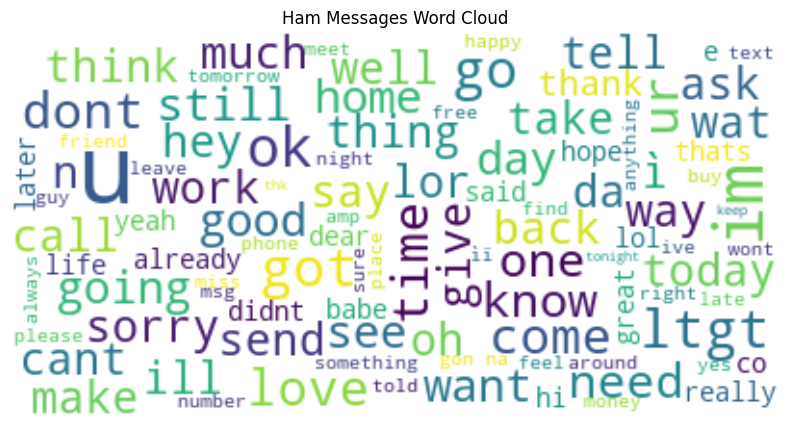

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(max_font_size=50, max_words=100, background_color='white').generate(' '.join(ham['text_clean_1']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Ham Messages Word Cloud')

### Exercise 1(i) (5 points)

Create a word-cloud of `text_clean_1` from the `spam` data-frame. 

Text(0.5, 1.0, 'Spam Messages Word Cloud')

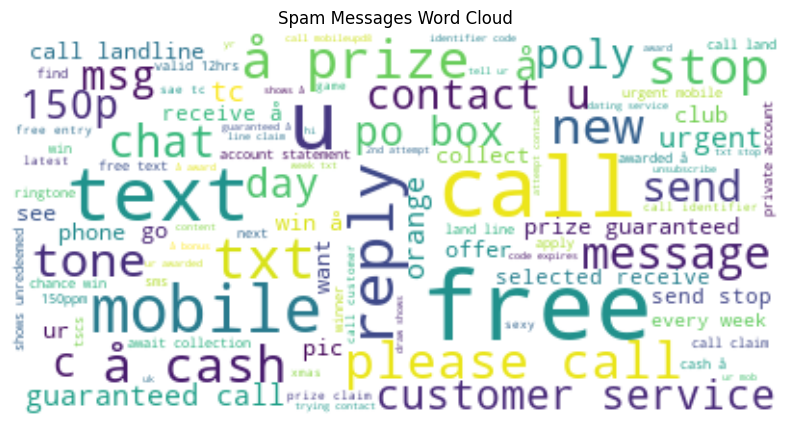

In [12]:
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color='white').generate(' '.join(spam['text_clean_1']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Spam Messages Word Cloud')